In [78]:
import xarray as xr

### CM4

In [79]:
data = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/cm4_piControl_ocean_200yr_full_chunked.zarr", chunks={}
)
# cm4_piControl_ocean_200yr_full_chunked.zarr
data

<xarray.Dataset> Size: 458GB
Dimensions:               (time: 14600, lat: 180, lon: 360)
Coordinates:
  * lat                   (lat) float64 1kB -89.24 -88.25 -87.25 ... 88.25 89.24
  * lon                   (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * time                  (time) object 117kB 0151-01-06 00:00:00 ... 0351-01...
Data variables: (12/141)
    EXT                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    HI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    HS                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    UI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    VI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    evs                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    ...                    ...
    vo_6                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_7                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_8                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_9                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    wfo                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    zos                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
Attributes:
    history:        Dataset computed by full-model/scripts/data_process/compu...
    regrid_method:  conservative

In [80]:
sea_surface_fraction = data["sea_surface_fraction"]

In [58]:
# data = data.isel(time=slice(None, 100))

In [59]:
old_data = xr.open_zarr(
    "/global/cfs/cdirs/m4874/suryad/data/CM4_5daily_v0.4.0_preprocessed.zarr", chunks={}
)

In [60]:
v = "mask"
levels = old_data.lev.values
level_numbers = [i for i in range(19)]
sorted_vars = [v + "_" + str(lev) for lev in level_numbers]
mask = xr.concat([data[var] for var in sorted_vars], dim="lev")
mask = mask.assign_coords(lev=levels)

In [61]:
v = "thetao"
levels = old_data.lev.values
level_numbers = [i for i in range(19)]
sorted_vars = [v + "_" + str(lev) for lev in level_numbers]
thetao = xr.concat([data[var] for var in sorted_vars], dim="lev")
thetao = thetao.assign_coords(lev=levels)
thetao = thetao.rename("thetao")
# areacello = spherical_area_weights(thetao)
thetao = thetao.transpose("time", "lev", ...)
thetao["areacello"] = (["lat", "lon"], old_data.areacello.values)
thetao["dz"] = ("lev", old_data.dz.values)

In [62]:
hfds = data["hfds"]
hfgeou = data["hfgeou"]

In [64]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

OHC = (
    ((thetao * c_p * rho_0) * thetao["areacello"] * thetao["dz"])
    .sum(["lat", "lon", "lev"])
    .compute()
)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="J")

In [65]:
time = 5 * 24 * 60 * 60
hfds_int = (
    (hfds.cumsum("time") * thetao["areacello"] * time).sum(["lat", "lon"]).compute()
)

In [66]:
time = 5 * 24 * 60 * 60
hfds_geo_int = (
    ((hfds + hfgeou).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [67]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac_int = (
    (
        ((hfds) * data.sea_surface_fraction + hfgeou).cumsum("time")
        * thetao["areacello"]
        * time
    )
    .sum(["lat", "lon"])
    .compute()
)

In [68]:
time_slice = slice(None, None)

In this plot, we correct our model to fit the red line - CM4 HFDS (with sea surface fraction) + Geothermal and "optimizing" for the blue line. We are not REALLY optimizing since we are only optimizing for next step prediction and no global ocean heat loss consideration

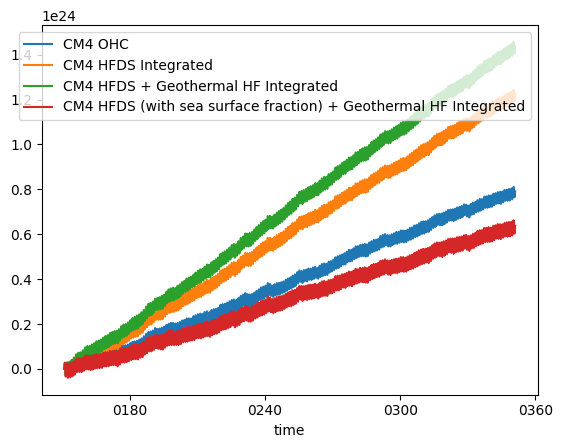

In [69]:
import matplotlib.pyplot as plt

(OHC.isel(time=time_slice) - OHC.isel(time=0)).plot(label="CM4 OHC")
hfds_int.isel(time=time_slice).plot(label="CM4 HFDS Integrated")
hfds_geo_int.isel(time=time_slice).plot(label="CM4 HFDS + Geothermal HF Integrated")
hfds_geo_seafrac_int.isel(time=time_slice).plot(
    label="CM4 HFDS (with sea surface fraction) + Geothermal HF Integrated"
)

plt.title("")
plt.ylabel("")
plt.legend()
plt.show()

### OM4

In [70]:
data = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/3D_data_OM4_5daily_v0.2.1_with_hfds_anomalies",
    chunks={},
)
# cm4_piControl_ocean_200yr_full_chunked.zarr
data

<xarray.Dataset> Size: 100GB
Dimensions:            (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello          (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 152B dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 152B 2.5 10.0 22.5 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b              (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction     (lev, y, x) float64 10MB dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) object 38kB 1958-01-03 12:00:00 ... 2022-12-29 ...
    wetmask            (lev, y, x) bool 1MB dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * y                  (y) float64 1kB -89.24 -88.25 -87.25 ... 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    hfds               (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies     (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1050_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_105_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10_0        (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1400_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    vo_lev_5000_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_550_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_65_0        (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_775_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [71]:
data = data.rename({"lon": "lon_t", "lat": "lat_t"})
data = data.rename({"x": "lon", "y": "lat"})

In [72]:
v = "thetao"
levels = old_data.lev.values
sorted_vars = [v + "_lev_" + str(lev).replace(".", "_") for lev in levels]
thetao = xr.concat([data[var] for var in sorted_vars], dim="lev")
thetao = thetao.assign_coords(lev=levels)
thetao = thetao.rename("thetao")
# areacello = spherical_area_weights(thetao)
thetao = thetao.transpose("time", "lev", ...)
thetao["areacello"] = (["lat", "lon"], old_data.areacello.values)
thetao["dz"] = ("lev", old_data.dz.values)

In [90]:
hfds = data["hfds"]

In [74]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

OHC = (
    ((thetao * c_p * rho_0) * thetao["areacello"] * thetao["dz"])
    .sum(["lat", "lon", "lev"])
    .compute()
)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="J")

In [91]:
time = 5 * 24 * 60 * 60
hfds_int = (
    (hfds.cumsum("time") * thetao["areacello"] * time).sum(["lat", "lon"]).compute()
)

In [99]:
time = 5 * 24 * 60 * 60
hfds_geo_int = (
    ((hfds + hfgeou.isel(time=0)).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [106]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac_int = (
    (
        ((hfds) * sea_surface_fraction.isel(time=0) + hfgeou.isel(time=0)).cumsum(
            "time"
        )
        * thetao["areacello"]
        * time
    )
    .sum(["lat", "lon"])
    .compute()
)

In [107]:
time_slice = slice(None, None)

In [118]:
OHC.time

<xarray.DataArray 'time' (time: 4745)> Size: 38kB
array([cftime.DatetimeJulian(1958, 1, 3, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 8, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 13, 12, 0, 0, 0, has_year_zero=False),
       ...,
       cftime.DatetimeJulian(2022, 12, 19, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 24, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 29, 12, 0, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
  * time     (time) object 38kB 1958-01-03 12:00:00 ... 2022-12-29 12:00:00

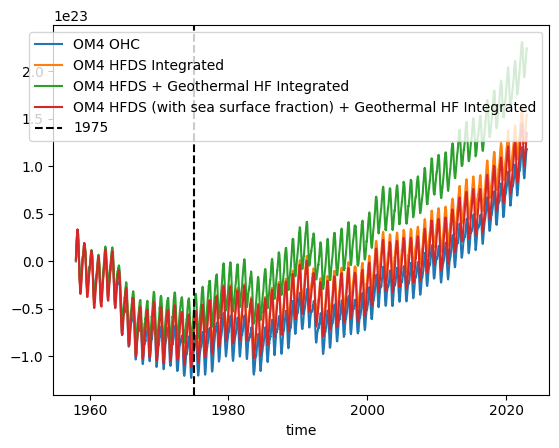

In [120]:
import matplotlib.pyplot as plt
import cftime

(OHC.isel(time=time_slice) - OHC.isel(time=0)).plot(label="OM4 OHC")
hfds_int.isel(time=time_slice).plot(label="OM4 HFDS Integrated")
hfds_geo_int.isel(time=time_slice).plot(label="OM4 HFDS + Geothermal HF Integrated")
hfds_geo_seafrac_int.isel(time=time_slice).plot(
    label="OM4 HFDS (with sea surface fraction) + Geothermal HF Integrated"
)
plt.axvline(
    x=cftime.DatetimeJulian(1975, 1, 3, 12, 0, 0, 0, has_year_zero=False),
    linestyle="--",
    color="k",
    label="1975",
)

plt.title("")
plt.ylabel("")
plt.legend()
plt.show()